# DSAIT4335 Recommender Systems
# Assignment 2: Collaborative Filtering

In this assignment, you will work to build different recommendation models under Collaborative Filtering approach, including user-based and item-based neighborhood models, and matrix factorization. Then, you will apply these recommendation models on a public dataset. The dataset is **MovieLens100K**, a movie recommendation dataset collected by GroupLens: https://grouplens.org/datasets/movielens/100k/.

By the end of this assignment, you will:
1. Understand the fundamental principles of collaborative filtering approach
2. Implement user-based and item-based neighborhood methods
3. Develop recommendation generation and prediction with SLIM and MF models
4. Perform both rating prediction and top-k recommendation tasks
5. Evaluate collaborative filtering methods to understand their strengths/limitations

# Instruction

The MovieLens100K is already splitted into 80% training and 20% test sets. 

**Expected file structure** for this assignment:   
   
   ```
   Assignment2/
   ├── training.txt
   ├── test.txt
   └── hw2.ipynb
   ```

**Note:** Be sure to run all cells in each section sequentially, so that intermediate variables and packages are properly carried over to subsequent cells.

**Submission:** Answer all the questions in this jupyter-notebook file. Submit this jupyter-notebook file (your answers included) to Brightspace. Change the name of this jupyter-notebook file to your name: firstname-lastname.ipynb.

# Setup

Import necessary libraries/packages.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.spatial.distance import cosine, correlation
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import time, math
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


# 1) MovieLens100K dataset

Load the data files: training and test sets.

In [25]:
# loading the training set and test set
columns_name=['user_id','item_id','rating','timestamp']
train_data = pd.read_csv('training.txt', sep='\t', names=columns_name)
test_data = pd.read_csv('test.txt', sep='\t', names=columns_name)

print(f'The training data:')
display(train_data[['user_id','item_id','rating']].head())
print(f'The shape of the training data: {train_data.shape}')
print('--------------------------------')
print(f'The test data:')
display(test_data[['user_id','item_id','rating']].head())
print(f'The shape of the test data: {test_data.shape}')
# print(test_data.shape)

The training data:


,user_id,item_id,rating
0,1,1,5
1,1,2,3
2,1,3,4
3,1,4,3
4,1,5,3


The shape of the training data: (80000, 4)
--------------------------------
The test data:


,user_id,item_id,rating
0,1,6,5
1,1,10,3
2,1,12,5
3,1,14,5
4,1,17,3


The shape of the test data: (20000, 4)


In [26]:
print(f'All columns of the training data:')
display(train_data.head())

print(f'All columns of the test data:')
display(test_data.head())

# In both datasets, we have a timestep column.

All columns of the training data:


,user_id,item_id,rating,timestamp
0,1,1,5,874965758
1,1,2,3,876893171
2,1,3,4,878542960
3,1,4,3,876893119
4,1,5,3,889751712


All columns of the test data:


,user_id,item_id,rating,timestamp
0,1,6,5,887431973
1,1,10,3,875693118
2,1,12,5,878542960
3,1,14,5,874965706
4,1,17,3,875073198


# 2) User-based collaborative filtering

### Question 1: Implement a function that computes the Pearson Correlation between two users. 

The **Pearson correlation coefficient** between two users \(x\) and \(y\) is defined as:

$$
r_{xy} = \frac{\sum_{i \in I_{xy}} (x_i - \bar{x})(y_i - \bar{y})}
              {\sqrt{\sum_{i \in I_{xy}} (x_i - \bar{x})^2} \cdot \sqrt{\sum_{i \in I_{xy}} (y_i - \bar{y})^2}}
$$

**Where:**

- $I_{xy}$ = set of items rated by both users  
- $x_i$, $y_i$ = ratings of users \(x\) and \(y\) on item \(i\)  
- $\bar{x}$, $\bar{y}$ = mean ratings of users \(x\) and \(y\) on the common items  


In [27]:
def pearson_correlation(user1_ratings: pd.Series, user2_ratings: pd.Series) -> float:
    """
    Compute Pearson correlation coefficient between two users' rating vectors.
    
    user1_ratings, user2_ratings: Pandas Series indexed by item IDs. They may contain NaN for unrated items.
    Returns: float (correlation between -1 and 1). Returns 0 if not enough data.
    """
    result = 0.0
    
    ############# Your code here ############

    # Find set of items rated by both users
    s1, s2 = user1_ratings.align(user2_ratings, join="inner")
    mask = s1.notna() & s2.notna()
    x, y = s1[mask].astype(float), s2[mask].astype(float)

    #print("Ratings of the common items by user1:", x)
    #print("Ratings of the common items by user2:", y)

    # We need at least 2 ratings to compute pearson correlation 
    # Ensure denominator is not zero
    if x.size < 2:
        return 0.0

    mean_X = x.mean()
    mean_Y = y.mean()

    diff_X = x - mean_X
    diff_Y = y - mean_Y

    num = (diff_X * diff_Y).sum()
    denom = math.sqrt((diff_X * diff_X).sum()) * math.sqrt((diff_Y * diff_Y).sum())
    if denom == 0.0 or not np.isfinite(denom):
        return 0.0

    result = num / denom

    #########################################
    
    return result

user1, user2 = 1, 2
user1_ratings = train_data[train_data['user_id'] == user1].set_index('item_id')['rating']
user2_ratings = train_data[train_data['user_id'] == user2].set_index('item_id')['rating']
print(f"Pearson Correlation between users {user1} and {user2} is {pearson_correlation(user1_ratings, user2_ratings):.4f}")

Pearson Correlation between users 1 and 2 is 0.2697


### Question 2: What is the similarity value between users <8,9>. Discuss your observation.

In [28]:
user1, user2 = 9, 8
sim = 0.0

############# Your code here ############

# Find pearson correlation value between user1 and user2
user1_ratings = train_data[train_data['user_id'] == user1].set_index('item_id')['rating']
user2_ratings = train_data[train_data['user_id'] == user2].set_index('item_id')['rating']

sim = pearson_correlation(user1_ratings, user2_ratings)

#########################################

print(f"Pearson Correlation between users {user1} and {user2} is {sim:.4f}")

Pearson Correlation between users 9 and 8 is 0.0000


The reason for getting a zero similarity score for users <8,9> is because they don't have any commonly rated items. Without this data, we cannot compute the similarity score. 

### Question 3: What is the similarity value between users <2,3>? Discuss your observation.

In [29]:
user1, user2 = 2, 3
sim = 0.0

############# Your code here ############

# Find pearson correlation value between user1 and user2
user1_ratings = train_data[train_data['user_id'] == user1].set_index('item_id')['rating']
user2_ratings = train_data[train_data['user_id'] == user2].set_index('item_id')['rating']

sim = pearson_correlation(user1_ratings, user2_ratings)

#########################################

print(f"Pearson Correlation between users {user1} and {user2} is {sim:.4f}")

Pearson Correlation between users 2 and 3 is 0.0000


The reason for getting a zero similarity score for users <2,3> is because user 3 has zero variance in its predictions of the common items. Hence, the denominator becomes zero due to the factor "y - y_mean". Hence, we get a zero similarity score.

### Question 4: Create the user-user similarity matrix.

In [30]:
def compute_user_similarity_matrix(train_data: pd.DataFrame) -> pd.DataFrame:
    """
    Compute user-user similarity matrix using Pearson correlation.
    
    Parameters:
    - ratings: pd.DataFrame with columns ['user_id', 'item_id', 'rating']
    
    Returns:
    - pd.DataFrame: user-user similarity matrix (rows & cols = user_ids)
    """
    users = train_data['user_id'].unique()
    user_similarity_matrix = pd.DataFrame(np.zeros((len(users), len(users))), index=users, columns=users) # Create a user x user similarity matrix
    
    ############# Your code here ############

    for i in range(len(users)):
        for j in range(i, len(users)):  # compute only upper triangle (to speed up the computation)
            user1_id = users[i]
            user2_id = users[j]

            user1_ratings = train_data[train_data['user_id'] == user1_id].set_index('item_id')['rating']
            user2_ratings = train_data[train_data['user_id'] == user2_id].set_index('item_id')['rating']

            sim = pearson_correlation(user1_ratings, user2_ratings)
            user_similarity_matrix[user1_id][user2_id] = sim   # fill in the upper cell
            user_similarity_matrix[user2_id][user1_id] = sim   # reflect on the lower cell
                        
    #########################################
    
    return user_similarity_matrix

# start_time = time.time()
# print(f'Similarity matrix creation started! This may take around 5-10 minutes...')
# user_similarity_matrix = compute_user_similarity_matrix(train_data)  
# end_time = time.time()
# print(f'Running time: {end_time - start_time:.4f} seconds')

In [31]:
from pathlib import Path
from utils import save_similarity_matrix, load_similarity_matrix

latest_path = Path("artifacts/similarity/user_sim_latest.parquet")

if latest_path.exists():
    print("Loading cached user similarity matrix…")
    user_similarity_matrix = load_similarity_matrix(str(latest_path))
else:
    start_time = time.time()
    print("Computing user similarity matrix…")
    user_similarity_matrix = compute_user_similarity_matrix(train_data)
    user_paths = save_similarity_matrix(user_similarity_matrix, name="user")
    print("Similarity matrix is saved in the directory:", user_paths)  
    end_time = time.time()
    print(f'Running time: {end_time - start_time:.4f} seconds')

Loading cached user similarity matrix…


### Question 5: Implement a function that returns k most similar users along with the similarity values to a target user.

In [32]:
def get_k_user_neighbors(user_similarity_matrix: pd.DataFrame, target_user, k=5):
    """
    Retrieve top-k most similar users to the target user.

    Parameters:
    - user_similarity_matrix: pd.DataFrame, user-user similarity values (indexed by user IDs)
    - target_user: user ID for whom we want neighbors
    - k: number of neighbors to retrieve

    Returns:
    - List of tuples: [(neighbor_user_id, similarity), ...] sorted by similarity descending
    """
    top_k_neighbors = []
    
    ############# Your code here ############

    sorted_neighbors = user_similarity_matrix[target_user].sort_values(ascending=False)
    top_neighbors = sorted_neighbors[:k]
    for neighbor, sim in top_neighbors.items():
        top_k_neighbors.append((neighbor, sim))
    
    #########################################
    
    return top_k_neighbors

target_user, k = 1, 10
print(f"Neighbors of user {target_user} are:")
get_k_user_neighbors(user_similarity_matrix, target_user, k)

Neighbors of user 1 are:


[(926, 1.0000000000000002),
 (289, 1.0000000000000002),
 (46, 1.0000000000000002),
 (29, 1.0000000000000002),
 (920, 1.0000000000000002),
 (656, 1.0000000000000002),
 (123, 1.0),
 (732, 1.0),
 (740, 1.0),
 (898, 1.0)]

### Question 6: Implement a function that predicts the rating for a target user might give to a target item using user-user similarity matrix and the following equation.

The **predicted rating** for a target user \(u\) on item \(i\) using mean-centered user-based collaborative filtering is:

$$
\hat{r}_{u,i} = \bar{r}_u + \frac{\sum_{v \in N(u)} s(u,v) \cdot (r_{v,i} - \bar{r}_v)}
                             {\sum_{v \in N(u)} |s(u,v)|}
$$

Where:

- $\hat{r}_{u,i}$ = predicted rating for user \(u\) on item \(i\)  
- $\bar{r}_u$ = mean rating of the target user \(u\)  
- $N(u)$ = set of top-\(k\) neighbors of user \(u\) who have rated item \(i\)  
- $s(u,v)$ = similarity between users \(u\) and \(v\)  
- $r_{v,i}$ = rating of neighbor \(v\) on item \(i\)  
- $\bar{r}_v$ = mean rating of neighbor \(v\)


In [33]:
def predict_rating_user_based(train_data: pd.DataFrame, user_similarity_matrix: pd.DataFrame, target_user, target_item, k=5):
    """
    Predict rating for target_user and target_item using mean-centered user-based CF.

    Parameters:
    - ratings: pd.DataFrame with columns ['user_id', 'item_id', 'rating']
    - user_similarity_matrix: pd.DataFrame of user-user similarities
    - target_user: user ID
    - target_item: item ID
    - k: number of neighbors to consider

    Returns:
    - float: predicted rating, or np.nan if not possible
    """
    result = 0.0
    
    ############# Your code here ############

    # Define minimum and maximum possible values for rating predictions
    rmin=1.0
    rmax=5.0

    # Find the top-k neighbors of the target user and select only those who have rated the target item
    top_k_neighbors = get_k_user_neighbors(user_similarity_matrix, target_user, k)
    selected_neighbors = []
    for neighbor, sim in top_k_neighbors:
        if neighbor in train_data[train_data['item_id'] == target_item]['user_id'].unique():
            neighbor_rating = train_data[(train_data['user_id'] == neighbor) & (train_data['item_id'] == target_item)]['rating'].values[0]
            selected_neighbors.append((neighbor, sim, neighbor_rating))

    # If there are not any neighbors who rated on the same item, return the mean rating of the target user
    mean_rating = train_data[train_data['user_id'] == target_user]['rating'].mean()
    if len(selected_neighbors) == 0:
        return float(np.clip(mean_rating, rmin, rmax))

    sim_sum = sum([abs(sim) for _, sim, _ in selected_neighbors])
    if sim_sum == 0:
        return float(np.clip(mean_rating, rmin, rmax))
    
    num = 0.0
    # Calculate the weighted average rating based on the similarity scores of the neighbors
    for neighbor, sim, neighbor_rating in selected_neighbors:
        mean_neighbor_rating = train_data[(train_data['user_id'] == neighbor)]['rating'].mean()
        num += sim * (neighbor_rating - mean_neighbor_rating)

    result = mean_rating + (num / sim_sum)

    #########################################

    return result

target_user, target_item, k = 1, 17, 50
print(f"The actual rating for user {target_user} and item {target_item} is 3. The predicted rating by user-based CF for user {target_user} and item {target_item} is {predict_rating_user_based(train_data, user_similarity_matrix, target_user, target_item, k):.4f}")

The actual rating for user 1 and item 17 is 3. The predicted rating by user-based CF for user 1 and item 17 is 4.9473


### Question 7: Implement a function that generates top-10 recommendation list for a target user using user-based CF method.

In [34]:
def recommend_topk_user_based(train_data, user_similarity_matrix, target_user, k=5, n=10):
    """
    Generate Top-K recommendations for a target user using User-based CF.
    
    Args:
        train_data (pd.DataFrame): ratings data with columns [user_id, item_id, rating]
        user_similarity_matrix (pd.DataFrame): precomputed user-user similarity matrix
        target_user (int): user_id of the target user
        k (int): number of most similar neighbors to consider
    
    Returns:
        list of (item_id, predicted_score) sorted by score desc
    """
    result = []
    
    ############# Your code here ############

    preds = []
    for item in train_data['item_id'].unique():
        pred_score = predict_rating_user_based(train_data, user_similarity_matrix, target_user, item, k)
        preds.append((item, pred_score))
    
    preds.sort(key=lambda x: x[1], reverse=True) # Sort in descending order of predicted scores
    result = preds[:n] # Select top-n items with highest ratings

    #########################################
    
    return result

start_time = time.time()
target_user, k = 1, 50
recommendations = recommend_topk_user_based(train_data, user_similarity_matrix, target_user, k)
print(f"Top-10 recommendations for user {target_user}:")
for item, score in recommendations:
    print(f"Item {item}: {score:.4f}")
end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

Top-10 recommendations for user 1:
Item 889: 5.6430
Item 97: 5.5877
Item 275: 5.4940
Item 129: 5.4037
Item 896: 5.3440
Item 62: 5.2220
Item 969: 5.2121
Item 309: 5.1815
Item 515: 5.1552
Item 137: 5.1179
Running time: 8.0800 seconds


# 3) Item-based collaborative filtering

### Question 8: Implement a function that computes the Cosine similarity between two items. 

The **cosine similarity** between two items \(i\) and \(j\) is defined as:

$$
\text{sim}(i,j) = \frac{\sum_{u \in U_{ij}} r_{u,i} \cdot r_{u,j}}
                      {\sqrt{\sum_{u \in U_{ij}} r_{u,i}^2} \cdot \sqrt{\sum_{u \in U_{ij}} r_{u,j}^2}}
$$

Where:

- \(r_{u,i}\) = rating of user \(u\) on item \(i\)  
- \(r_{u,j}\) = rating of user \(u\) on item \(j\)  
- \(U_{ij}\) = set of users who have rated both items \(i\) and \(j\)  


In [35]:
def cosine_similarity(item1_ratings: pd.Series, item2_ratings: pd.Series) -> float:
    """
    Compute cosine similarity between two items' rating vectors.
    Only common users are considered.
    
    Parameters:
    - item1_ratings, item2_ratings: pd.Series indexed by user_id
    
    Returns:
    - float: cosine similarity between -1 and 1
    """
    result = 0.0
    
    ############# Your code here ############

    i1, i2 = item1_ratings.align(item2_ratings, join='inner')
    mask = i1.notna() & i2.notna()
    x, y = i1[mask].astype(float), i2[mask].astype(float)

    #print("Ratings for item1 by common users", x)
    #print("Ratings for item2 by common users", y)

    # We need at least 2 ratings to compute cosine similarity
    if x.size < 2:
        return 0.0
    
    num = (x * y).sum()
    denom = math.sqrt((x * x).sum()) * math.sqrt((y * y).sum())
    if denom == 0.0 or not np.isfinite(denom):
        return 0.0

    result = num / denom
    
    #########################################

    return result

item1, item2 = 1, 2
item1_ratings = train_data[train_data['item_id'] == item1].set_index('user_id')['rating']
item2_ratings = train_data[train_data['item_id'] == item2].set_index('user_id')['rating']
print(f"Cosine similarity between items {item1} and {item2} is {cosine_similarity(item1_ratings, item2_ratings):.4f}")

Cosine similarity between items 1 and 2 is 0.9500


### Question 9: Create the item-item similarity matrix.

In [36]:
def compute_item_similarity_matrix(train_data: pd.DataFrame) -> pd.DataFrame:
    """
    Compute item-item similarity matrix using cosine similarity.
    
    Parameters:
    - ratings: pd.DataFrame with columns ['user_id', 'item_id', 'rating']
    
    Returns:
    - pd.DataFrame: item-item similarity matrix (rows & cols = item_ids)
    """
    items = train_data['item_id'].unique()
    item_similarity_matrix = pd.DataFrame(np.zeros((len(items), len(items))), index=items, columns=items)
    
    ############# Your code here ############

    for i in range(len(items)):
        for j in range(i, len(items)): # compute only upper triangle (to speed up the computation)
            item1_id = items[i]
            item2_id = items[j]

            item1_ratings = train_data[train_data['item_id'] == item1_id].set_index('user_id')['rating']
            item2_ratings = train_data[train_data['item_id'] == item2_id].set_index('user_id')['rating']

            sim = cosine_similarity(item1_ratings, item2_ratings)
            item_similarity_matrix[item1_id][item2_id] = sim   # fill in the upper cell
            item_similarity_matrix[item2_id][item1_id] = sim   # reflect on the lower cell
    
    #########################################
    
    return item_similarity_matrix

# start_time = time.time()
# item_similarity_matrix = compute_item_similarity_matrix(train_data)  
# end_time = time.time()
# print(f'Running time: {end_time - start_time:.4f} seconds')

In [37]:
from pathlib import Path
from utils import save_similarity_matrix, load_similarity_matrix

latest_path = Path("artifacts/similarity/item_sim_latest.parquet")

if latest_path.exists():
    print("Loading cached item similarity matrix…")
    item_similarity_matrix = load_similarity_matrix(str(latest_path))
else:
    start_time = time.time()
    print("Computing item similarity matrix…")
    item_similarity_matrix = compute_item_similarity_matrix(train_data)
    item_paths = save_similarity_matrix(item_similarity_matrix, name="item")
    print("Similarity matrix is saved in the directory:", item_paths)  
    end_time = time.time()
    print(f'Running time: {end_time - start_time:.4f} seconds')

Loading cached item similarity matrix…


### Question 10: Implement a function that returns k most similar item along with the similarity values to a target item.

In [38]:
def get_k_item_neighbors(item_similarity_matrix: pd.DataFrame, target_item, k=5):
    """
    Retrieve top-k most similar items to the target item.
    
    Parameters:
    - item_similarity_matrix: pd.DataFrame, item-item similarity
    - target_item: item ID
    - k: number of neighbors
    
    Returns:
    - List of tuples: [(neighbor_item_id, similarity), ...]
    """
    top_k_neighbors = []

    ############# Your code here ############

    if target_item not in item_similarity_matrix.columns:
        return []

    sorted_neighbors = item_similarity_matrix[target_item].sort_values(ascending=False)
    top_neighbors = sorted_neighbors[:k]
    for neighbor, sim in top_neighbors.items():
        top_k_neighbors.append((neighbor, sim))
    
    #########################################
    
    return top_k_neighbors

target_item, k = 1, 10
print(f"Neighbors of item {target_item} are:")
get_k_item_neighbors(item_similarity_matrix, target_item, k)

Neighbors of item 1 are:


[(1, 1.0),
 (1024, 1.0),
 (1445, 1.0),
 (938, 1.0),
 (757, 1.0),
 (1150, 1.0),
 (1534, 1.0),
 (592, 0.9999999999999999),
 (1189, 0.9999999999999999),
 (954, 0.9999999999999999)]

### Question 11: Implement a function that predicts the rating for a target user might give to a target item using item-item similarity matrix and the following equation.

The **predicted rating** for a target user \(u\) on a target item \(i\) using item-based collaborative filtering is:

$$
\hat{r}_{u,i} = \frac{\sum_{j \in N(i)} s(i,j) \cdot r_{u,j}}{\sum_{j \in N(i)} |s(i,j)|}
$$

Where:

- \(\hat{r}_{u,i}\) = predicted rating of user \(u\) on item \(i\)  
- \(N(i)\) = set of top-\(k\) most similar items to item \(i\) that user \(u\) has rated  
- \(s(i,j)\) = similarity between item \(i\) and item \(j\)  
- \(r_{u,j}\) = rating of user \(u\) on item \(j\)  


In [39]:
def predict_rating_item_based(train_data: pd.DataFrame, item_similarity_matrix: pd.DataFrame, target_user, target_item, k=5):
    """
    Predict rating using item-based CF (non-mean centric).
    
    Parameters:
    - ratings: pd.DataFrame ['user_id', 'item_id', 'rating']
    - item_similarity_matrix: item-item similarity DataFrame
    - target_user: user ID
    - target_item: item ID
    - k: number of neighbors to use
    
    Returns:
    - float: predicted rating, or np.nan if not enough data
    """
    result = 0.0

    ############# Your code here ############

    if target_item not in item_similarity_matrix.columns:
        return train_data[train_data['user_id'] == target_user]['rating'].mean() # Return user mean rating

    top_k_neighbors = get_k_item_neighbors(item_similarity_matrix, target_item, k)
    selected_neighbors = [] # In this case, neighbors are the items
    for item_neighbor, sim in top_k_neighbors:
        # If the target user has rated the neighbor item
        if item_neighbor in train_data[train_data['user_id'] == target_user]['item_id'].unique():
            neighbor_rating = train_data[(train_data['user_id'] == target_user) & (train_data['item_id'] == item_neighbor)]['rating'].values[0]
            selected_neighbors.append((item_neighbor, sim, neighbor_rating))

    sim_sum = sum([abs(sim) for _, sim, _ in selected_neighbors])
    if sim_sum == 0:
        return 0.0
    
    numerator = 0.0
    # Calculate the weighted average rating based on the similarity scores of the neighbors
    for _, sim, neighbor_rating in selected_neighbors:
        numerator += sim * neighbor_rating

    result += numerator / sim_sum

    #########################################
    
    return result

target_user, target_item, k = 1, 17, 50
print(f"The actual rating for user {target_user} and item {target_item} is 3. The predicted rating by item-based CF for user {target_user} and item {target_item} is {predict_rating_item_based(train_data, item_similarity_matrix, target_user, target_item, k):.4f}")

The actual rating for user 1 and item 17 is 3. The predicted rating by item-based CF for user 1 and item 17 is 2.3376


### Question 12: Implement a function that generates top-10 recommendation list for a target user using item-based CF method.

In [40]:
def recommend_topk_item_based(train_data, item_similarity_matrix, target_user, k=5, n=10):
    """
    Generate Top-K recommendations for a target user using Item-based CF.
    
    Args:
        train_data (pd.DataFrame): ratings data with columns [user_id, item_id, rating]
        item_similarity_matrix (pd.DataFrame): precomputed item-item similarity matrix
        target_user (int): user_id of the target user
        k (int): number of items to recommend
    
    Returns:
        list of (item_id, predicted_score) sorted by score desc
    """
    result = []

    ############# Your code here ############

    preds = []
    for item in train_data['item_id'].unique():
        pred_score = predict_rating_item_based(train_data, item_similarity_matrix, target_user, item, k) # Here, k is the number of neighbors used for score predictions
        preds.append((item, pred_score))

    preds.sort(key=lambda x: x[1], reverse=True) # Sort in descending order of predicted scores
    result = preds[:n]  

    #########################################
    
    return result

target_user, k = 1, 50
recommendations = recommend_topk_item_based(train_data, item_similarity_matrix, target_user, k)
print(f"Top-10 recommendations for user {target_user}:")
for item, score in recommendations:
    print(f"Item {item}: {score:.4f}")

Top-10 recommendations for user 1:
Item 586: 5.0000
Item 670: 5.0000
Item 49: 5.0000
Item 630: 5.0000
Item 871: 5.0000
Item 945: 5.0000
Item 720: 5.0000
Item 705: 5.0000
Item 1127: 5.0000
Item 1321: 5.0000


# 3) Matrix Factorization (MF)

For details about matrix factorization algorithm see the lecture in week 3.

Matrix factorization algorithm is implemented in the next cell. Run the following cell and then use it to build MF model for running experiments.

In [41]:
class MatrixFactorizationSGD:
    """
    Matrix Factorization for rating prediction using Stochastic Gradient Descent (SGD).
    
    Rating matrix R ≈ P x Q^T + biases
    """
    def __init__(self, n_factors=20, learning_rate=0.01, regularization=0.02, n_epochs=20, use_bias=True):
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.regularization = regularization
        self.n_epochs = n_epochs
        self.use_bias = use_bias

        # Model parameters
        self.P = None  # User latent factors
        self.Q = None  # Item latent factors
        self.user_bias = None
        self.item_bias = None
        self.global_mean = None

    def fit(self, ratings, verbose=True):
        """
        Train the model.
        
        Args:
            ratings (pd.DataFrame): dataframe with [user_id, item_id, rating]
        """
        # Map IDs to indices
        self.user_mapping = {u: i for i, u in enumerate(ratings['user_id'].unique())}
        self.item_mapping = {i: j for j, i in enumerate(ratings['item_id'].unique())}
        self.user_inv = {i: u for u, i in self.user_mapping.items()}
        self.item_inv = {j: i for i, j in self.item_mapping.items()}

        n_users = len(self.user_mapping)
        n_items = len(self.item_mapping)

        # Initialize factors
        self.P = np.random.normal(0, 0.1, (n_users, self.n_factors))
        self.Q = np.random.normal(0, 0.1, (n_items, self.n_factors))

        if self.use_bias:
            self.user_bias = np.zeros(n_users)
            self.item_bias = np.zeros(n_items)
            self.global_mean = ratings['rating'].mean()

        # Convert to (user_idx, item_idx, rating) triples
        training_data = [(self.user_mapping[u], self.item_mapping[i], r)
                         for u, i, r in zip(ratings['user_id'], ratings['item_id'], ratings['rating'])]

        # SGD loop
        for epoch in range(self.n_epochs):
            np.random.shuffle(training_data)
            total_error = 0

            for u, i, r in training_data:
                pred = np.dot(self.P[u], self.Q[i])
                if self.use_bias:
                    pred += self.global_mean + self.user_bias[u] + self.item_bias[i]

                err = r - pred
                total_error += err ** 2

                # Updates
                P_u = self.P[u]
                Q_i = self.Q[i]

                self.P[u] += self.learning_rate * (err * Q_i - self.regularization * P_u)
                self.Q[i] += self.learning_rate * (err * P_u - self.regularization * Q_i)

                if self.use_bias:
                    self.user_bias[u] += self.learning_rate * (err - self.regularization * self.user_bias[u])
                    self.item_bias[i] += self.learning_rate * (err - self.regularization * self.item_bias[i])

            rmse = np.sqrt(total_error / len(training_data))
            if verbose:
                print(f"Epoch {epoch+1}/{self.n_epochs} - RMSE: {rmse:.4f}")

        return self

    def predict_single(self, user_id, item_id):
        """Predict rating for a single (user, item) pair"""
        if user_id not in self.user_mapping or item_id not in self.item_mapping:
            return np.nan

        u = self.user_mapping[user_id]
        i = self.item_mapping[item_id]

        pred = np.dot(self.P[u], self.Q[i])
        if self.use_bias:
            pred += self.global_mean + self.user_bias[u] + self.item_bias[i]
        return pred

    def predict(self, test_data):
        """Predict ratings for a test dataframe with [user_id, item_id]"""
        preds = []
        for u, i in zip(test_data['user_id'], test_data['item_id']):
            preds.append(self.predict_single(u, i))
        return np.array(preds)

    def recommend_topk(self, user_id, train_data, n=10, exclude_seen=True):
        """
        Generate Top-K recommendations for a given user.

        Args:
            user_id (int): target user ID (original ID, not index).
            train_data (pd.DataFrame): training ratings [user_id, item_id, rating],
                                       used to exclude already-seen items.
            k (int): number of recommendations.
            exclude_seen (bool): whether to exclude items the user already rated.

        Returns:
            list of (item_id, predicted_score) sorted by score desc.
        """
        if user_id not in self.user_mapping:
            return []

        u = self.user_mapping[user_id]

        # Predict scores for all items
        scores = np.dot(self.P[u], self.Q.T)
        if self.use_bias:
            scores += self.global_mean + self.user_bias[u] + self.item_bias

        # Exclude seen items
        if exclude_seen:
            seen_items = train_data[train_data['user_id'] == user_id]['item_id'].values
            seen_idx = [self.item_mapping[i] for i in seen_items if i in self.item_mapping]
            scores[seen_idx] = -np.inf

        # Get top-K items
        top_idx = np.argsort(scores)[::-1][:n]
        top_items = [self.item_inv[i] for i in top_idx]
        top_scores = scores[top_idx]

        return list(zip(top_items, top_scores))

#### Sample usage for rating prediction task:

In [43]:
# Train model 
# Parameters: n_factors refers to embedding size, n_epochs refers to number of epochs, learning_rate refers to learning rate, and regularization refers to lambda hyperparameter controlling the effect of regularization terms
mf = MatrixFactorizationSGD(n_factors=50, n_epochs=10, learning_rate=0.001, regularization=0.001)
mf.fit(train_data, verbose=True)

# predict the rating for a target user and a target item
target_user = 1
target_item = 17
actual_rating = 3
pred_rating = mf.predict_single(target_user, target_item)
print(f"The actual rating for user {target_user} and item {target_item} is 3. The predicted rating by MF for user {target_user} and item {target_item} is {pred_rating:.4f}")

Epoch 1/10 - RMSE: 1.0958
Epoch 2/10 - RMSE: 1.0566
Epoch 3/10 - RMSE: 1.0305
Epoch 4/10 - RMSE: 1.0118
Epoch 5/10 - RMSE: 0.9977
Epoch 6/10 - RMSE: 0.9866
Epoch 7/10 - RMSE: 0.9776
Epoch 8/10 - RMSE: 0.9702
Epoch 9/10 - RMSE: 0.9638
Epoch 10/10 - RMSE: 0.9583
The actual rating for user 1 and item 17 is 3. The predicted rating by MF for user 1 and item 17 is 3.5122


#### Sample usage for ranking task:

In [ ]:
# Train model 
# Parameters: n_factors refers to embedding size, n_epochs refers to number of epochs, learning_rate refers to learning rate, and regularization refers to lambda hyperparameter controlling the effect of regularization terms
mf = MatrixFactorizationSGD(n_factors=10, n_epochs=10, learning_rate=0.001, regularization=0.001)
mf.fit(train_data, verbose=True)

# Get top-10 recommendations for user 1
recommendations = mf.recommend_topk(user_id=1, train_data=train_data, n=10)
print("Top-10 Recommendations for user 1:")
for item, score in recommendations:
    print(f"Item {item}: {score:.4f}")

Epoch 1/10 - RMSE: 1.0944
Epoch 2/10 - RMSE: 1.0559
Epoch 3/10 - RMSE: 1.0306
Epoch 4/10 - RMSE: 1.0126
Epoch 5/10 - RMSE: 0.9992
Epoch 6/10 - RMSE: 0.9889
Epoch 7/10 - RMSE: 0.9806
Epoch 8/10 - RMSE: 0.9738
Epoch 9/10 - RMSE: 0.9682
Epoch 10/10 - RMSE: 0.9634
Top-10 Recommendations for user 1:
Item 318: 4.4106
Item 12: 4.3796
Item 483: 4.3546
Item 98: 4.3517
Item 64: 4.3158
Item 313: 4.3135
Item 174: 4.2892
Item 603: 4.2892
Item 357: 4.2874
Item 408: 4.1929


# 4) Evaluation of user-based, item-based, and MF models for rating prediction task

### Question 13: What is the performance of user-based CF in terms of RMSE for k=50?

In [ ]:
def evaluate_user_cf_rating_prediction(train_data: pd.DataFrame, test_data: pd.DataFrame, user_similarity_matrix: pd.DataFrame, k=5) -> float:
    """
    Evaluate user-based CF using RMSE on a test set.
    
    Parameters:
    - train_data: pd.DataFrame with ['user_id', 'item_id', 'rating'] used for training
    - test_data: pd.DataFrame with ['user_id', 'item_id', 'rating'] used for testing
    - user_similarity_matrix: user-user similarity matrix (computed from train set)
    - k: number of neighbors
    
    Returns:
    - float: RMSE value
    """
    result = 0.0

    ############# Your code here ############

    # Compute RMSE
    sum_diff = 0.0
    for row in test_data.itertuples():
        user = row.user_id
        target_item = row.item_id
        pred = predict_rating_user_based(train_data, user_similarity_matrix, user, target_item, k)
        sum_diff += (row.rating - pred) ** 2
    result = np.sqrt(sum_diff / len(test_data))
    
    #########################################

    return result

k = 50
start_time = time.time()
print(f"RMSE of user-based CF for k={k} is {evaluate_user_cf_rating_prediction(train_data, test_data, user_similarity_matrix, k):.4f}")
end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

RMSE of user-based CF for k=50 is 1.1255
Running time: 112.7573 seconds


### Question 14: Can you further improve the performance of user-based CF? Tune user-based CF with k={10, 30, 50, 70, 100} and visualize the performance with k values in x-axis and corresponding RMSE values in y-axis.

RMSE of user-based CF for k=10 is 1.1248
RMSE of user-based CF for k=30 is 1.1320
RMSE of user-based CF for k=50 is 1.1255
RMSE of user-based CF for k=70 is 1.1115
RMSE of user-based CF for k=100 is 1.0838


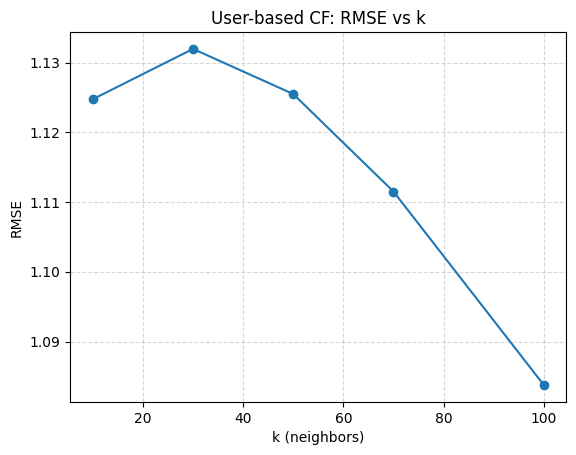

Running time: 607.3713 seconds


In [ ]:
K = [10,30,50,70,100]
user_based_RMSEs = []

start_time = time.time()

############# Your code here ############

for k_value in K:
    rmse = evaluate_user_cf_rating_prediction(train_data, test_data, user_similarity_matrix, k_value)
    user_based_RMSEs.append(rmse)
    print(f"RMSE of user-based CF for k={k_value} is {rmse:.4f}")

# Plot RMSE vs K
plt.figure()
plt.plot(K, user_based_RMSEs, marker='o')
plt.xlabel("k (neighbors)")
plt.ylabel("RMSE")
plt.title("User-based CF: RMSE vs k")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#########################################

end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

### Question 15: What is the performance of item-based CF in terms of RMSE for k=50?

In [ ]:
def evaluate_item_cf_rating_prediction(train_data: pd.DataFrame, test_data: pd.DataFrame, item_similarity_matrix: pd.DataFrame, k=5) -> float:
    """
    Evaluate item-based CF using RMSE on a test set.
    
    Parameters:
    - train_data: pd.DataFrame with ['user_id', 'item_id', 'rating'] used for training
    - test_data: pd.DataFrame with ['user_id', 'item_id', 'rating'] used for testing
    - item_similarity_matrix: item-item similarity matrix (computed from train set)
    - k: number of neighbors
    
    Returns:
    - float: RMSE value
    """
    result = 0.0

    ############# Your code here ############

    # Compute RMSE
    sum_diff = 0.0
    for row in test_data.itertuples():
        user = row.user_id
        target_item = row.item_id
        pred = predict_rating_item_based(train_data, item_similarity_matrix, user, target_item, k)
        sum_diff += (row.rating - pred) ** 2
    result = np.sqrt(sum_diff / len(test_data))
    
    #########################################

    return result

k = 50
start_time = time.time()
print(f"RMSE of item-based CF for k={k} is {evaluate_item_cf_rating_prediction(train_data, test_data, item_similarity_matrix, k):.4f}")
end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

RMSE of item-based CF for k=50 is 2.9661
Running time: 96.7482 seconds


### Question 16: Can you further improve the performance of item-based CF? Tune item-based CF with k={10, 30, 50, 70, 100} and visualize the performance with k values in x-axis and corresponding RMSE values in y-axis.

RMSE of item-based CF for k=10 is 3.4750
RMSE of item-based CF for k=30 is 3.1944
RMSE of item-based CF for k=50 is 2.9661
RMSE of item-based CF for k=70 is 2.7580
RMSE of item-based CF for k=100 is 2.4220


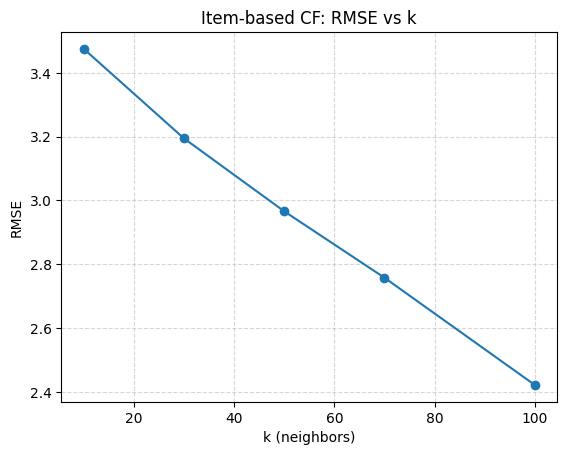

Running time: 499.6605 seconds


In [ ]:
K = [10,30,50,70,100]
item_based_RMSEs = []

start_time = time.time()

############# Your code here ############

for k_value in K:
    rmse = evaluate_item_cf_rating_prediction(train_data, test_data, item_similarity_matrix, k_value)
    item_based_RMSEs.append(rmse)
    print(f"RMSE of item-based CF for k={k_value} is {rmse:.4f}")

# Plot RMSE vs K
plt.figure()
plt.plot(K, item_based_RMSEs, marker='o')
plt.xlabel("k (neighbors)")
plt.ylabel("RMSE")
plt.title("Item-based CF: RMSE vs k")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
    
#########################################

end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

*Here are my observations:*

As we increase the number of neighbors used when predicting a rating for a target user and target item, the RMSE decreases for both user- and item-based CF. This suggests that collaborative filtering performance improves when we base our predictions on a higher number of similar items or users (depending on the type of CF we are implementing).

This is the expected result because increasing k means averaging the known ratings over more neighbors, which usually reduces variance by smoothing out the predictions. As a result of this variance reduction, test RMSE tends to get reduced with the increase in k.

### Question 17: What is the performance of MF model in terms of RMSE for the following hyperparameter values?

    n_factors=50

    n_epochs=30

    learning_rate=0.001

    regularization=0.001

In [61]:
def evaluate_mf_rating_prediction(train_data: pd.DataFrame, test_data: pd.DataFrame, n_factors: float, n_epochs: float, learning_rate: float) -> float:
    """
    Evaluate MF using RMSE on a test set.
    
    Parameters:
    - train_data: pd.DataFrame with ['user_id', 'item_id', 'rating'] used for training
    - test_data: pd.DataFrame with ['user_id', 'item_id', 'rating'] used for testing
    - n_factors: embedding size
    - n_epochs: number of training epochs
    - learning_rate: Learning rate
    
    Returns:
    - float: RMSE value
    """
    # Hint: set the regularization hyperparameter to 0.001

    result = 0.0

    ############# Your code here ############

    # Train model 
    # Parameters: n_factors refers to embedding size, n_epochs refers to number of epochs, learning_rate refers to learning rate, and regularization refers to lambda hyperparameter controlling the effect of regularization terms
    mf = MatrixFactorizationSGD(n_factors=50, n_epochs=30, learning_rate=0.001, regularization=0.001)
    mf.fit(train_data, verbose=True)
    preds = mf.predict(test_data)
    y_true = test_data['rating'].values

    # Fallbacks for NaN predictions 
    user_means = train_data.groupby('user_id')['rating'].mean()
    
    if np.isnan(preds).any():
        filled = []
        for (u, _), p in zip(test_data[['user_id', 'item_id']].itertuples(index=False, name=None), preds):
            if np.isfinite(p):
                filled.append(p)
            else:
                m = user_means.get(u, np.nan)
                filled.append(float(m))
        preds = np.array(filled, dtype=float)
    
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    print(f"RMSE of MF for n_factors={n_factors}, n_epochs={n_epochs}, learning_rate={learning_rate} is {rmse:.4f}")
    
    #########################################
    
    return rmse

n_factors, n_epochs, learning_rate = 50, 30, 0.001
start_time = time.time()
print(f"RMSE of MF for n_factors={n_factors}, n_epochs={n_epochs}, learning_rate={learning_rate} is {evaluate_mf_rating_prediction(train_data, test_data, n_factors, n_epochs, learning_rate):.4f}")
end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

Epoch 1/30 - RMSE: 1.0958
Epoch 2/30 - RMSE: 1.0565
Epoch 3/30 - RMSE: 1.0304
Epoch 4/30 - RMSE: 1.0116
Epoch 5/30 - RMSE: 0.9975
Epoch 6/30 - RMSE: 0.9864
Epoch 7/30 - RMSE: 0.9774
Epoch 8/30 - RMSE: 0.9699
Epoch 9/30 - RMSE: 0.9635
Epoch 10/30 - RMSE: 0.9580
Epoch 11/30 - RMSE: 0.9531
Epoch 12/30 - RMSE: 0.9488
Epoch 13/30 - RMSE: 0.9448
Epoch 14/30 - RMSE: 0.9412
Epoch 15/30 - RMSE: 0.9379
Epoch 16/30 - RMSE: 0.9348
Epoch 17/30 - RMSE: 0.9319
Epoch 18/30 - RMSE: 0.9292
Epoch 19/30 - RMSE: 0.9266
Epoch 20/30 - RMSE: 0.9241
Epoch 21/30 - RMSE: 0.9218
Epoch 22/30 - RMSE: 0.9195
Epoch 23/30 - RMSE: 0.9173
Epoch 24/30 - RMSE: 0.9152
Epoch 25/30 - RMSE: 0.9132
Epoch 26/30 - RMSE: 0.9111
Epoch 27/30 - RMSE: 0.9092
Epoch 28/30 - RMSE: 0.9072
Epoch 29/30 - RMSE: 0.9053
Epoch 30/30 - RMSE: 0.9035
RMSE of MF for n_factors=50, n_epochs=30, learning_rate=0.001 is 0.9717
RMSE of MF for n_factors=50, n_epochs=30, learning_rate=0.001 is 0.9717
Running time: 14.9318 seconds


### Question 18: Tune MF model with n_factors={10, 30, 50, 70, 90} and the rest of hyperparameters as n_epochs=30, learning_rate=0.001. Visualize the performance with n_factors in x-axis and corresponding RMSE values in y-axis.

Epoch 1/30 - RMSE: 1.0960
Epoch 2/30 - RMSE: 1.0568
Epoch 3/30 - RMSE: 1.0306
Epoch 4/30 - RMSE: 1.0119
Epoch 5/30 - RMSE: 0.9977
Epoch 6/30 - RMSE: 0.9866
Epoch 7/30 - RMSE: 0.9776
Epoch 8/30 - RMSE: 0.9701
Epoch 9/30 - RMSE: 0.9637
Epoch 10/30 - RMSE: 0.9582
Epoch 11/30 - RMSE: 0.9533
Epoch 12/30 - RMSE: 0.9490
Epoch 13/30 - RMSE: 0.9450
Epoch 14/30 - RMSE: 0.9414
Epoch 15/30 - RMSE: 0.9381
Epoch 16/30 - RMSE: 0.9350
Epoch 17/30 - RMSE: 0.9320
Epoch 18/30 - RMSE: 0.9293
Epoch 19/30 - RMSE: 0.9267
Epoch 20/30 - RMSE: 0.9242
Epoch 21/30 - RMSE: 0.9219
Epoch 22/30 - RMSE: 0.9196
Epoch 23/30 - RMSE: 0.9174
Epoch 24/30 - RMSE: 0.9152
Epoch 25/30 - RMSE: 0.9131
Epoch 26/30 - RMSE: 0.9111
Epoch 27/30 - RMSE: 0.9091
Epoch 28/30 - RMSE: 0.9072
Epoch 29/30 - RMSE: 0.9052
Epoch 30/30 - RMSE: 0.9033
RMSE of MF for n_factors=10, n_epochs=30, learning_rate=0.001 is 2.4220
RMSE of MF for n_factors=10, n_epochs=30, learning_rate=0.001 is 0.9714
Epoch 1/30 - RMSE: 1.0965
Epoch 2/30 - RMSE: 1.0573
Epo

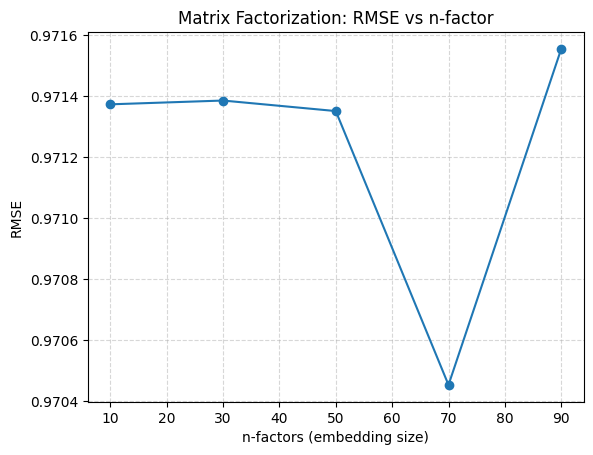

Running time: 85.7811 seconds


In [ ]:
n_factors = [10,30,50,70,90]
n_epochs, learning_rate = 30, 0.001
mf_RMSEs = []

start_time = time.time()

############# Your code here ############

for factor in n_factors:
    rmse = evaluate_mf_rating_prediction(train_data, test_data, factor, n_epochs, learning_rate)
    mf_RMSEs.append(rmse)
    print(f"RMSE of MF for n_factors={factor}, n_epochs={n_epochs}, learning_rate={learning_rate} is {rmse:.4f}")

# Plot RMSE vs n_factor
plt.figure()
plt.plot(n_factors, mf_RMSEs, marker='o')
plt.xlabel("n-factors (embedding size)")
plt.ylabel("RMSE")
plt.title("Matrix Factorization: RMSE vs n-factor")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
    
#########################################

end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

*Here are my observations:*

Unlike item- and user-based CF, RMSE does not always decrease as we increase the number of factors (the embedding size). When n_factors is increased from 70 to 90, we observe that RMSE increases significantly. This signals that the n_factors parameter needs hyperparameter tuning to select the best value for the predictions. We cannot just select the highest possible value for n_factors. 

Unlike increasing k in the CF algorithms, increasing n_factors in Matrix Factorization adds parameters to the model. This increased number of parameters tend to result in overfitting, which explains the above graph.

### Question 19: Tune MF model with n_epochs={10, 30, 50, 70, 90} and the rest of hyperparameters as n_factors=10, learning_rate=0.001. Visualize the performance with n_epochs in x-axis and corresponding RMSE values in y-axis.

Epoch 1/30 - RMSE: 1.0961
Epoch 2/30 - RMSE: 1.0569
Epoch 3/30 - RMSE: 1.0307
Epoch 4/30 - RMSE: 1.0120
Epoch 5/30 - RMSE: 0.9978
Epoch 6/30 - RMSE: 0.9867
Epoch 7/30 - RMSE: 0.9777
Epoch 8/30 - RMSE: 0.9702
Epoch 9/30 - RMSE: 0.9638
Epoch 10/30 - RMSE: 0.9583
Epoch 11/30 - RMSE: 0.9534
Epoch 12/30 - RMSE: 0.9491
Epoch 13/30 - RMSE: 0.9451
Epoch 14/30 - RMSE: 0.9415
Epoch 15/30 - RMSE: 0.9382
Epoch 16/30 - RMSE: 0.9351
Epoch 17/30 - RMSE: 0.9322
Epoch 18/30 - RMSE: 0.9295
Epoch 19/30 - RMSE: 0.9269
Epoch 20/30 - RMSE: 0.9244
Epoch 21/30 - RMSE: 0.9220
Epoch 22/30 - RMSE: 0.9198
Epoch 23/30 - RMSE: 0.9176
Epoch 24/30 - RMSE: 0.9155
Epoch 25/30 - RMSE: 0.9134
Epoch 26/30 - RMSE: 0.9114
Epoch 27/30 - RMSE: 0.9094
Epoch 28/30 - RMSE: 0.9075
Epoch 29/30 - RMSE: 0.9056
Epoch 30/30 - RMSE: 0.9037
RMSE of MF for n_factors=10, n_epochs=10, learning_rate=0.001 is 0.9713
RMSE of MF for n_factors=10, n_epochs=10, learning_rate=0.001 is 0.9719
Epoch 1/30 - RMSE: 1.0963
Epoch 2/30 - RMSE: 1.0571
Epo

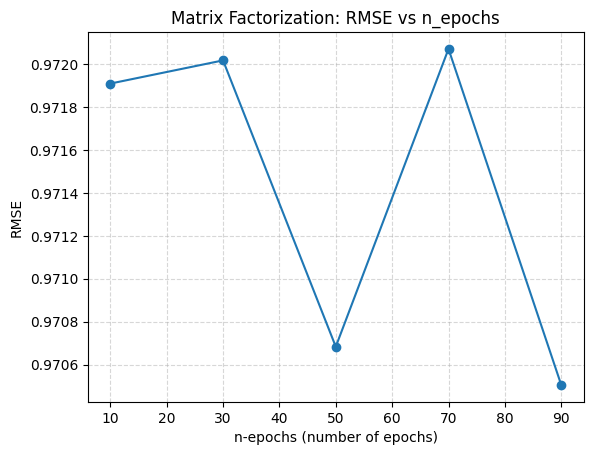

Running time: 87.2818 seconds


In [ ]:
n_epochs = [10,30,50,70,90]
n_factors, learning_rate = 10, 0.001
mf_RMSEs = []

start_time = time.time()

############# Your code here ############

for epoch in n_epochs:
    rmse = evaluate_mf_rating_prediction(train_data, test_data, n_factors, epoch, learning_rate)
    mf_RMSEs.append(rmse)
    print(f"RMSE of MF for n_factors={n_factors}, n_epochs={epoch}, learning_rate={learning_rate} is {rmse:.4f}")

# Plot RMSE vs n_factor
plt.figure()
plt.plot(n_epochs, mf_RMSEs, marker='o')
plt.xlabel("n-epochs (number of epochs)")
plt.ylabel("RMSE")
plt.title("Matrix Factorization: RMSE vs n_epochs")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
    
#########################################

end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

*Here are my observations:*

The trend for the number of epochs vs. RMSE is non-monotonic, meaning it oscillates. The reason behind these oscillations might be due to a constant learning rate. Due to the SGD noise, the predictions are sometimes closer and other times more distant to the real values. 

### Question 20: Tune MF model with learning_rate={0.001, 0.005, 0.01, 0.05} and the rest of hyperparameters as n_factors=10, n_epochs=90. Visualize the performance with learning rate in x-axis and corresponding RMSE values in y-axis.

Epoch 1/30 - RMSE: 1.0960
Epoch 2/30 - RMSE: 1.0567
Epoch 3/30 - RMSE: 1.0306
Epoch 4/30 - RMSE: 1.0118
Epoch 5/30 - RMSE: 0.9977
Epoch 6/30 - RMSE: 0.9866
Epoch 7/30 - RMSE: 0.9776
Epoch 8/30 - RMSE: 0.9702
Epoch 9/30 - RMSE: 0.9638
Epoch 10/30 - RMSE: 0.9583
Epoch 11/30 - RMSE: 0.9534
Epoch 12/30 - RMSE: 0.9491
Epoch 13/30 - RMSE: 0.9452
Epoch 14/30 - RMSE: 0.9416
Epoch 15/30 - RMSE: 0.9383
Epoch 16/30 - RMSE: 0.9352
Epoch 17/30 - RMSE: 0.9324
Epoch 18/30 - RMSE: 0.9296
Epoch 19/30 - RMSE: 0.9271
Epoch 20/30 - RMSE: 0.9246
Epoch 21/30 - RMSE: 0.9223
Epoch 22/30 - RMSE: 0.9201
Epoch 23/30 - RMSE: 0.9179
Epoch 24/30 - RMSE: 0.9158
Epoch 25/30 - RMSE: 0.9138
Epoch 26/30 - RMSE: 0.9118
Epoch 27/30 - RMSE: 0.9098
Epoch 28/30 - RMSE: 0.9079
Epoch 29/30 - RMSE: 0.9061
Epoch 30/30 - RMSE: 0.9042
RMSE of MF for n_factors=10, n_epochs=90, learning_rate=0.001 is 0.9705
RMSE of MF for n_factors=10, n_epochs=90, learning_rate=0.001 is 0.9714
Epoch 1/30 - RMSE: 1.0968
Epoch 2/30 - RMSE: 1.0575
Epo

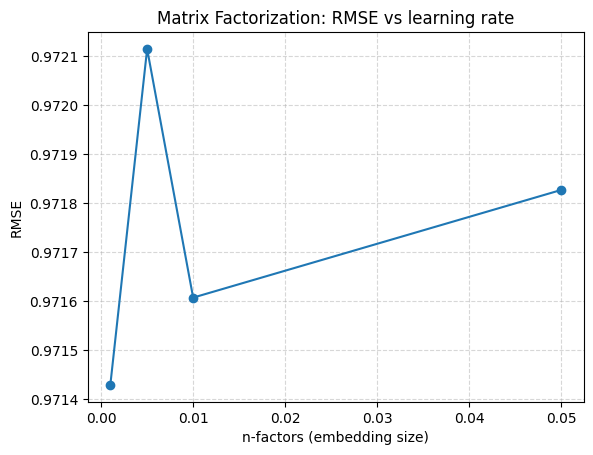

Running time: 69.8314 seconds


In [ ]:
learning_rate = [0.001,0.005,0.01,0.05]
n_factors, n_epochs = 10, 90
mf_RMSEs = []

start_time = time.time()

############# Your code here ############

for rate in learning_rate:
    rmse = evaluate_mf_rating_prediction(train_data, test_data, n_factors, n_epochs, rate)
    mf_RMSEs.append(rmse)
    print(f"RMSE of MF for n_factors={n_factors}, n_epochs={n_epochs}, learning_rate={rate} is {rmse:.4f}")

# Plot RMSE vs n_factor
plt.figure()
plt.plot(learning_rate, mf_RMSEs, marker='o')
plt.xlabel("n-factors (embedding size)")
plt.ylabel("RMSE")
plt.title("Matrix Factorization: RMSE vs learning rate")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
    
#########################################

end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

*Here are my observations:*

The above graph shows that a very small learning rate gives the best RMSE. The reason behind this observation might be that an SGD with a small step size trains steadily and acts like extra regularization. Hence, this results in a good generalization and a lower test RMSE.

# 6) Evaluation of user-based, item-based, and MF models for ranking task

In [44]:
def NDCG(ground_truth, rec_list):
    # Implement a function that computes NDCG across ground truth data and recommendation list generated for each user. 
    # Note that ground_truth and rec_list contain the list of items for all users, e.g., 2-dimensional arrays.
    
    ndcgs = []
    
    ############# Your code here ############

    for rated_items, recommended_items in zip(ground_truth, rec_list):
        relevance_set = set(rated_items)
        
        cumulative_dcg = 0.0
        cumulative_idcg = 0.0

        # Now loop over the recommended items (their order matters)
        for i, recommendation in enumerate(recommended_items, start=1): # Start at 1 because the rank starts at 1, not 0
            is_relevant = 1 if recommendation in relevance_set else 0
            curr_dcg = (2**is_relevant - 1) / np.log2(i + 1)
            cumulative_dcg += curr_dcg
            
        # Now compute the ndcg
        ideal_hits = min(len(relevance_set), len(recommended_items))
        if ideal_hits == 0:
            ndcgs.append(0.0)
            continue

        for i in range(1, ideal_hits + 1):
            curr_idcg = 1 / np.log2(i + 1)
            cumulative_idcg += curr_idcg

        ndcgs.append(cumulative_dcg / cumulative_idcg)

    result = np.mean(ndcgs)
    
    #########################################

    return result

### Question 21: What is the performance of user-based CF in terms of nDCG for k=30?

In [53]:
def evaluate_user_cf_ranking(train_data, test_data, user_similarity_matrix, k=5):
    """
    Evaluate User-based CF ranking performance using NDCG@K.
    
    Args:
        train_data (pd.DataFrame): training ratings [user_id, item_id, rating]
        test_data (pd.DataFrame): test ratings [user_id, item_id, rating]
        user_similarity_matrix (pd.DataFrame): precomputed user-user similarity matrix
        k (int): number of neighbors for prediction
    
    Returns:
        float: average NDCG@K across test users
    """

    ############# Your code here ############
    
    ground_truth, rec_list = [], []
    test_users = test_data['user_id'].unique()

    # Loop over the first 20 test users to compute the NDCG (otherwise it will take too long)
    for i, test_user_id in enumerate(test_users[:20]):
        # Step 1. Compute ground truth - all the items this user interacted with in the test set
        curr_gt = test_data[test_data['user_id'] == test_user_id]['item_id']
        ground_truth.append(curr_gt)

        # Step 2. Get the recommendation list for this user
        curr_rec = recommend_topk_user_based(train_data, user_similarity_matrix, test_user_id, k=k)
        rec_list.append([item for item, _ in curr_rec]) # Only append item ids

        #print(rec_list)
        print(f"Test user {i + 1} is processed.")
    
    ndcg_value = NDCG(ground_truth, rec_list)
    
    #########################################
    
    return ndcg_value

k = 30
start_time = time.time()
print(f"NDCG of user-based CF for k={k} is {evaluate_user_cf_ranking(train_data, test_data, user_similarity_matrix, k):.4f}")
end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

Test user 1 is processed.
Test user 2 is processed.
Test user 3 is processed.
Test user 4 is processed.
Test user 5 is processed.
Test user 6 is processed.
Test user 7 is processed.
Test user 8 is processed.
Test user 9 is processed.
Test user 10 is processed.
Test user 11 is processed.
Test user 12 is processed.
Test user 13 is processed.
Test user 14 is processed.
Test user 15 is processed.
Test user 16 is processed.
Test user 17 is processed.
Test user 18 is processed.
Test user 19 is processed.
Test user 20 is processed.
NDCG of user-based CF for k=30 is 0.1036
Running time: 106.7402 seconds


### Question 22: What is the performance of item-based CF in terms of nDCG for k=30?

In [54]:
def evaluate_item_cf_ranking(train_data, test_data, item_similarity_matrix, k=5):
    """
    Evaluate Item-based CF ranking performance using NDCG@K.
    
    Args:
        train_data (pd.DataFrame): training ratings [user_id, item_id, rating]
        test_data (pd.DataFrame): test ratings [user_id, item_id, rating]
        item_similarity_matrix (pd.DataFrame): precomputed item-item similarity matrix
        k (int): number of neighbors for prediction
    
    Returns:
        float: average NDCG@K across test users
    """

    ############# Your code here ############

    ground_truth, rec_list = [], []
    test_users = test_data['user_id'].unique()

    # Loop over the first 20 test users to compute the NDCG (otherwise it will take too long)
    for i, test_user_id in enumerate(test_users[:20]):
        # Step 1. Compute ground truth - all the items this user interacted with in the test set
        curr_gt = test_data[test_data['user_id'] == test_user_id]['item_id']
        ground_truth.append(curr_gt)

        # Step 2. Get the recommendation list for this user
        curr_rec = recommend_topk_item_based(train_data, user_similarity_matrix, test_user_id, k=k)
        rec_list.append([item for item, _ in curr_rec]) # Only append item ids

        print(f"Test user {i + 1} is processed.")
    
    ndcg_value = 0.0
    ndcg_value = NDCG(ground_truth, rec_list)
    
    #########################################
    
    return ndcg_value

k = 30
start_time = time.time()
print(f"NDCG of item-based CF for k={k} is {evaluate_item_cf_ranking(train_data, test_data, item_similarity_matrix, k):.4f}")
end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

Test user 1 is processed.
Test user 2 is processed.
Test user 3 is processed.
Test user 4 is processed.
Test user 5 is processed.
Test user 6 is processed.
Test user 7 is processed.
Test user 8 is processed.
Test user 9 is processed.
Test user 10 is processed.
Test user 11 is processed.
Test user 12 is processed.
Test user 13 is processed.
Test user 14 is processed.
Test user 15 is processed.
Test user 16 is processed.
Test user 17 is processed.
Test user 18 is processed.
Test user 19 is processed.
Test user 20 is processed.
NDCG of item-based CF for k=30 is 0.0814
Running time: 63.7625 seconds


### Question 23: What is the performance of MF model in terms of NDCG for the following hyperparameter values?

    n_factors=50

    n_epochs=30

    learning_rate=0.001

    regularization=0.001

In [63]:
def evaluate_mf_ranking(train_data: pd.DataFrame, test_data: pd.DataFrame, n_factors: float, n_epochs: float, learning_rate: float) -> float:
    """
    Evaluate MF in terms of NDCG.
    
    Parameters:
    - train_data: pd.DataFrame with ['user_id', 'item_id', 'rating'] used for training
    - test_data: pd.DataFrame with ['user_id', 'item_id', 'rating'] used for testing
    - n_factors: embedding size
    - n_epochs: number of training epochs
    - learning_rate: Learning rate
    
    Returns:
    - float: NDCG value
    """
    # Hint: set the regularization hyperparameter to 0.001

    ############# Your code here ############

    # Train model 
    # Parameters: n_factors refers to embedding size, n_epochs refers to number of epochs, learning_rate refers to learning rate, and regularization refers to lambda hyperparameter controlling the effect of regularization terms
    mf = MatrixFactorizationSGD(n_factors=n_factors, learning_rate=learning_rate, n_epochs=n_epochs, regularization=0.001)
    mf.fit(train_data, verbose=True)

    ground_truth, rec_list = [], []
    test_users = test_data['user_id'].unique()

    # Loop over the first 20 test users to compute the NDCG (otherwise it will take too long)
    for i, test_user_id in enumerate(test_users[:20]):
        # Step 1. Compute ground truth - all the items this user interacted with in the test set
        curr_gt = test_data[test_data['user_id'] == test_user_id]['item_id']
        ground_truth.append(curr_gt)

        # Step 2. Get the recommendation list for this user
        curr_rec = mf.recommend_topk(user_id=1, train_data=train_data, n=10)
        rec_list.append([item for item, _ in curr_rec]) # Only append item ids

        #print(rec_list)
        print(f"Test user {i + 1} is processed.")

    ndcg_value = 0.0
    ndcg_value = NDCG(ground_truth, rec_list)
    
    #########################################
    
    return ndcg_value

n_factors, n_epochs, learning_rate = 50, 30, 0.001
start_time = time.time()
print(f"NDCG of MF for n_factors={n_factors}, n_epochs={n_epochs}, learning_rate={learning_rate} is {evaluate_mf_ranking(train_data, test_data, n_factors, n_epochs, learning_rate):.4f}")
end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

Epoch 1/30 - RMSE: 1.0961
Epoch 2/30 - RMSE: 1.0568
Epoch 3/30 - RMSE: 1.0307
Epoch 4/30 - RMSE: 1.0120
Epoch 5/30 - RMSE: 0.9978
Epoch 6/30 - RMSE: 0.9867
Epoch 7/30 - RMSE: 0.9777
Epoch 8/30 - RMSE: 0.9703
Epoch 9/30 - RMSE: 0.9639
Epoch 10/30 - RMSE: 0.9584
Epoch 11/30 - RMSE: 0.9535
Epoch 12/30 - RMSE: 0.9491
Epoch 13/30 - RMSE: 0.9452
Epoch 14/30 - RMSE: 0.9416
Epoch 15/30 - RMSE: 0.9383
Epoch 16/30 - RMSE: 0.9352
Epoch 17/30 - RMSE: 0.9323
Epoch 18/30 - RMSE: 0.9295
Epoch 19/30 - RMSE: 0.9270
Epoch 20/30 - RMSE: 0.9245
Epoch 21/30 - RMSE: 0.9221
Epoch 22/30 - RMSE: 0.9199
Epoch 23/30 - RMSE: 0.9177
Epoch 24/30 - RMSE: 0.9156
Epoch 25/30 - RMSE: 0.9135
Epoch 26/30 - RMSE: 0.9115
Epoch 27/30 - RMSE: 0.9095
Epoch 28/30 - RMSE: 0.9076
Epoch 29/30 - RMSE: 0.9057
Epoch 30/30 - RMSE: 0.9038
[[408, 483, 513, 318, 427, 12, 64, 285, 657, 480]]
Test user 1 is processed.
[[408, 483, 513, 318, 427, 12, 64, 285, 657, 480], [408, 483, 513, 318, 427, 12, 64, 285, 657, 480]]
Test user 2 is proces

### Question 24: Tune MF model with n_factors={10, 30, 50, 70, 90} and the rest of hyperparameters as n_epochs=30, learning_rate=0.001. Visualize the performance with n_factors in x-axis and corresponding NDCG values in y-axis.

Epoch 1/30 - RMSE: 1.0940
Epoch 2/30 - RMSE: 1.0556
Epoch 3/30 - RMSE: 1.0302
Epoch 4/30 - RMSE: 1.0123
Epoch 5/30 - RMSE: 0.9989
Epoch 6/30 - RMSE: 0.9885
Epoch 7/30 - RMSE: 0.9802
Epoch 8/30 - RMSE: 0.9735
Epoch 9/30 - RMSE: 0.9678
Epoch 10/30 - RMSE: 0.9630
Epoch 11/30 - RMSE: 0.9589
Epoch 12/30 - RMSE: 0.9553
Epoch 13/30 - RMSE: 0.9521
Epoch 14/30 - RMSE: 0.9492
Epoch 15/30 - RMSE: 0.9466
Epoch 16/30 - RMSE: 0.9443
Epoch 17/30 - RMSE: 0.9421
Epoch 18/30 - RMSE: 0.9401
Epoch 19/30 - RMSE: 0.9383
Epoch 20/30 - RMSE: 0.9366
Epoch 21/30 - RMSE: 0.9350
Epoch 22/30 - RMSE: 0.9335
Epoch 23/30 - RMSE: 0.9322
Epoch 24/30 - RMSE: 0.9308
Epoch 25/30 - RMSE: 0.9296
Epoch 26/30 - RMSE: 0.9284
Epoch 27/30 - RMSE: 0.9273
Epoch 28/30 - RMSE: 0.9262
Epoch 29/30 - RMSE: 0.9252
Epoch 30/30 - RMSE: 0.9242
[[408, 318, 483, 12, 64, 480, 603, 174, 98, 515]]
Test user 1 is processed.
[[408, 318, 483, 12, 64, 480, 603, 174, 98, 515], [408, 318, 483, 12, 64, 480, 603, 174, 98, 515]]
Test user 2 is processed

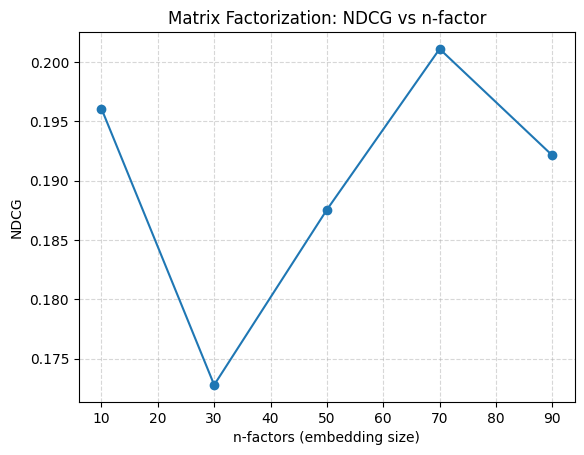

Running time: 76.0641 seconds


In [64]:
n_factors = [10,30,50,70,90]
n_epochs, learning_rate = 30, 0.001
mf_NDCGs = []

start_time = time.time()

############# Your code here ############

for factor in n_factors:
    ndcg = evaluate_mf_ranking(train_data, test_data, factor, n_epochs, learning_rate)
    mf_NDCGs.append(ndcg)
    print(f"NDCG of MF for n_factors={factor}, n_epochs={n_epochs}, learning_rate={learning_rate} is {ndcg:.4f}")

# Plot NDCG vs n_factor
plt.figure()
plt.plot(n_factors, mf_NDCGs, marker='o')
plt.xlabel("n-factors (embedding size)")
plt.ylabel("NDCG")
plt.title("Matrix Factorization: NDCG vs n-factor")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
    
#########################################

end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

### Question 25: Tune MF model with n_epochs={10, 30, 50, 70, 90} and the rest of hyperparameters as n_factors=30, learning_rate=0.001. Visualize the performance with n_epochs in x-axis and corresponding NDCG values in y-axis.

Epoch 1/10 - RMSE: 1.0951
Epoch 2/10 - RMSE: 1.0563
Epoch 3/10 - RMSE: 1.0305
Epoch 4/10 - RMSE: 1.0122
Epoch 5/10 - RMSE: 0.9984
Epoch 6/10 - RMSE: 0.9877
Epoch 7/10 - RMSE: 0.9791
Epoch 8/10 - RMSE: 0.9720
Epoch 9/10 - RMSE: 0.9660
Epoch 10/10 - RMSE: 0.9608
[[318, 64, 313, 357, 12, 483, 174, 98, 603, 134]]
Test user 1 is processed.
[[318, 64, 313, 357, 12, 483, 174, 98, 603, 134], [318, 64, 313, 357, 12, 483, 174, 98, 603, 134]]
Test user 2 is processed.
[[318, 64, 313, 357, 12, 483, 174, 98, 603, 134], [318, 64, 313, 357, 12, 483, 174, 98, 603, 134], [318, 64, 313, 357, 12, 483, 174, 98, 603, 134]]
Test user 3 is processed.
[[318, 64, 313, 357, 12, 483, 174, 98, 603, 134], [318, 64, 313, 357, 12, 483, 174, 98, 603, 134], [318, 64, 313, 357, 12, 483, 174, 98, 603, 134], [318, 64, 313, 357, 12, 483, 174, 98, 603, 134]]
Test user 4 is processed.
[[318, 64, 313, 357, 12, 483, 174, 98, 603, 134], [318, 64, 313, 357, 12, 483, 174, 98, 603, 134], [318, 64, 313, 357, 12, 483, 174, 98, 603,

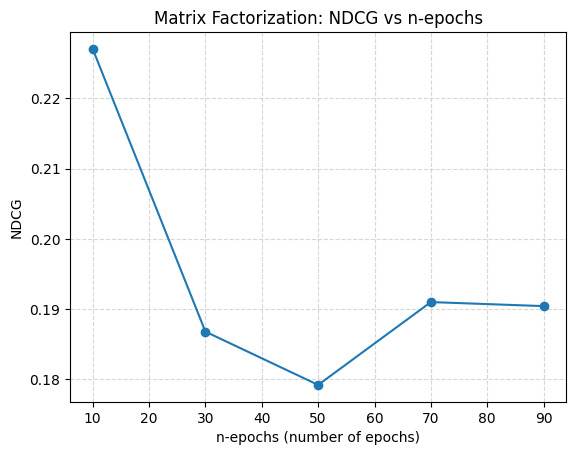

Running time: 131.9711 seconds


In [67]:
n_epochs = [10,30,50,70,90]
n_factors, learning_rate = 30, 0.001
mf_NDCGs = []

start_time = time.time()

############# Your code here ############

for epoch in n_epochs:
    ndcg = evaluate_mf_ranking(train_data, test_data, n_factors, epoch, learning_rate)
    mf_NDCGs.append(ndcg)
    print(f"NDCG of MF for n_factors={n_factors}, n_epochs={epoch}, learning_rate={learning_rate} is {ndcg:.4f}")

# Plot NDCG vs n_factor
plt.figure()
plt.plot(n_epochs, mf_NDCGs, marker='o')
plt.xlabel("n-epochs (number of epochs)")
plt.ylabel("NDCG")
plt.title("Matrix Factorization: NDCG vs n-epochs")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
    
#########################################

end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

### Question 26: Tune MF model with learning_rate={0.001, 0.005, 0.01, 0.05} and the rest of hyperparameters as n_factors=10, n_epochs=90. Visualize the performance with n_factors in x-axis and corresponding NDCG values in y-axis.

Epoch 1/90 - RMSE: 1.0942
Epoch 2/90 - RMSE: 1.0558
Epoch 3/90 - RMSE: 1.0304
Epoch 4/90 - RMSE: 1.0125
Epoch 5/90 - RMSE: 0.9991
Epoch 6/90 - RMSE: 0.9887
Epoch 7/90 - RMSE: 0.9804
Epoch 8/90 - RMSE: 0.9737
Epoch 9/90 - RMSE: 0.9680
Epoch 10/90 - RMSE: 0.9632
Epoch 11/90 - RMSE: 0.9591
Epoch 12/90 - RMSE: 0.9555
Epoch 13/90 - RMSE: 0.9523
Epoch 14/90 - RMSE: 0.9494
Epoch 15/90 - RMSE: 0.9468
Epoch 16/90 - RMSE: 0.9445
Epoch 17/90 - RMSE: 0.9424
Epoch 18/90 - RMSE: 0.9404
Epoch 19/90 - RMSE: 0.9386
Epoch 20/90 - RMSE: 0.9369
Epoch 21/90 - RMSE: 0.9353
Epoch 22/90 - RMSE: 0.9339
Epoch 23/90 - RMSE: 0.9325
Epoch 24/90 - RMSE: 0.9312
Epoch 25/90 - RMSE: 0.9299
Epoch 26/90 - RMSE: 0.9288
Epoch 27/90 - RMSE: 0.9277
Epoch 28/90 - RMSE: 0.9266
Epoch 29/90 - RMSE: 0.9256
Epoch 30/90 - RMSE: 0.9246
Epoch 31/90 - RMSE: 0.9237
Epoch 32/90 - RMSE: 0.9228
Epoch 33/90 - RMSE: 0.9219
Epoch 34/90 - RMSE: 0.9211
Epoch 35/90 - RMSE: 0.9203
Epoch 36/90 - RMSE: 0.9195
Epoch 37/90 - RMSE: 0.9187
Epoch 38/9

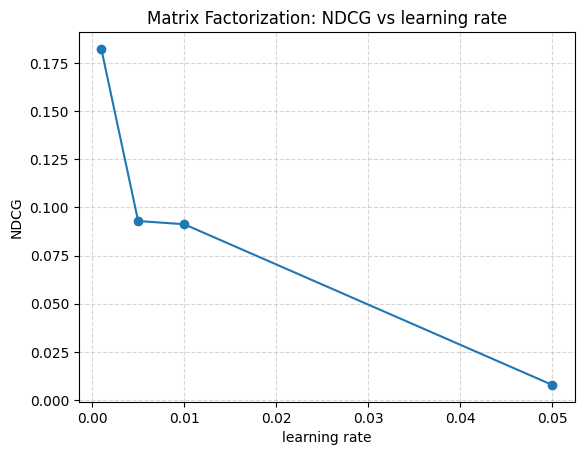

Running time: 187.3532 seconds


In [68]:
learning_rate = [0.001,0.005,0.01,0.05]
n_factors, n_epochs = 10, 90
mf_NDCGs = []

start_time = time.time()

############# Your code here ############

for rate in learning_rate:
    ndcg = evaluate_mf_ranking(train_data, test_data, n_factors, n_epochs, rate)
    mf_NDCGs.append(ndcg)
    print(f"NDCG of MF for n_factors={n_factors}, n_epochs={n_epochs}, learning_rate={rate} is {ndcg:.4f}")

# Plot NDCG vs n_factor
plt.figure()
plt.plot(learning_rate, mf_NDCGs, marker='o')
plt.xlabel("learning rate")
plt.ylabel("NDCG")
plt.title("Matrix Factorization: NDCG vs learning rate")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
    
#########################################

end_time = time.time()
print(f'Running time: {end_time - start_time:.4f} seconds')

# 7) Discussion

### Question 27: Compare the performance of CF methods with the content-based recommendation model developed in assignment 1. Discuss your observations.

*Performance of the CF methods:*
1. Rating Task
- Best RMSE of user-based CF for k=100: **1.0838**
- Best RMSE of item-based CF for k=100: **2.4220**

2. Ranking Task
- NDCG of user-based CF for k=30: **0.1036**
- NDCG of item-based CF for k=30: **0.0814**

*Performance of the best content-based predictor:*
1. Rating Task: best predictor was *full + avg*
- Best RMSE = **1.21568**

2. Ranking Task: best predictor was *description + avg*
- Best NDCG = **0.11872**

*My observations:*

On the rating task, user-based CF surpasses the performance of the best content-based predictor. However, item-based CF is significantly worse in performance (by almost a factor of two) than the content-based predictor.

On the ranking task, both user- and item-based CF methods outperform the content-based predictor, with item-based CF performing better than user-based CF on the ranking task.

*Possible reasons for these observations:*

User-based CF works well for the rating task because it makes the predictions well calibrated to each user by utilizing a mean rating term for each user. This results in a better RMSE value.

The reason why both user- and item-based CF methods outperform the content-based predictor might be that ranking cares about order, not scale. Even if item-CF scores are biased (too high or too low), the ordering of items similar to what the user liked is strong. This lifts NDCG despite poor RMSE.